In [1]:
import numpy as np
import pandas as pd
     

In [2]:
df = pd.read_csv('placement.csv')


In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,115,Yes
1,1,6.0,103,No
2,2,5.3,120,No
3,3,7.6,125,Yes
4,4,5.8,145,No


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  95 non-null     int64  
 1   cgpa        95 non-null     float64
 2   iq          95 non-null     int64  
 3   placement   95 non-null     str    
dtypes: float64(1), int64(2), str(1)
memory usage: 3.1 KB


In [5]:
df.shape 

(95, 4)

In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,115,Yes
1,6.0,103,No
2,5.3,120,No
3,7.6,125,Yes
4,5.8,145,No


In [8]:
import matplotlib.pyplot as plt

In [9]:
df['placement'] = df['placement'].map({'No': 0, 'Yes': 1})

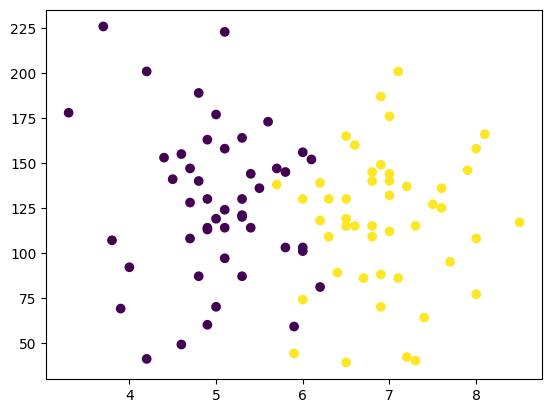

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
print(df.columns.tolist())

['cgpa', 'iq', 'placement']


In [12]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [13]:
X

,cgpa,iq
0,6.8,115
1,6.0,103
2,5.3,120
3,7.6,125
4,5.8,145
...,...,...
90,4.2,201
91,4.2,41
92,6.9,187
93,6.3,109


In [14]:
y.shape

(95,)

In [15]:

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [16]:
X_train

,cgpa,iq
85,4.7,147
20,6.9,149
19,6.6,115
67,8.5,117
14,5.0,177
...,...,...
55,6.5,130
54,5.9,59
84,4.5,141
1,6.0,103


In [17]:
y_train
     

85    0
20    1
19    1
67    1
14    0
     ..
55    1
54    0
84    0
1     0
27    0
Name: placement, Length: 85, dtype: int64

In [18]:
X_test

,cgpa,iq
40,5.3,121
81,5.6,173
8,6.1,152
25,7.1,201
66,3.9,69
80,7.5,127
47,6.8,140
86,7.1,86
79,6.5,39
62,6.9,70


In [19]:

from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
X_train = scaler.fit_transform(X_train)

In [22]:
X_train

array([[-1.05518313,  0.6100914 ],
       [ 0.82404778,  0.66151209],
       [ 0.56778902, -0.21263969],
       [ 2.19076116, -0.161219  ],
       [-0.79892437,  1.3814018 ],
       [-0.11556768,  0.55867071],
       [ 1.16572612, -0.21263969],
       [-0.88434395, -1.62670875],
       [ 0.0552715 ,  0.17301551],
       [ 1.76366323, -1.18963286],
       [ 0.0552715 ,  0.84148452],
       [-1.31144189,  0.76435348],
       [ 0.90946736,  0.43011897],
       [ 0.31153026,  0.17301551],
       [-0.88434395, -0.23835004],
       [ 0.73862819, -0.36690177],
       [-1.82395941, -0.41832246],
       [ 1.67824364,  0.58438105],
       [ 0.90946736,  0.53296036],
       [ 1.42198488,  0.04446378],
       [-1.90937899,  2.64120878],
       [ 0.22611067, -0.13550865],
       [-0.71350478,  0.89290521],
       [ 0.22611067, -1.08679147],
       [ 1.84908281,  1.09858799],
       [-0.45724602, -0.23835004],
       [-0.71350478,  2.56407774],
       [ 0.6532086 , -0.95823974],
       [-0.37182644,

In [23]:


X_test = scaler.transform(X_test)
     


In [24]:
X_test

array([[-0.54266561, -0.05837761],
       [-0.28640685,  1.27856041],
       [ 0.14069108,  0.73864313],
       [ 0.99488695,  1.99845012],
       [-1.73853982, -1.39531563],
       [ 1.33656529,  0.09588447],
       [ 0.73862819,  0.43011897],
       [ 0.99488695, -0.95823974],
       [ 0.48236943, -2.16662603],
       [ 0.82404778, -1.36960529]])

In [25]:

from sklearn.linear_model import LogisticRegression

In [26]:

clf = LogisticRegression()

In [27]:
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
y_pred = clf.predict(X_test)

In [29]:


y_test
     


40    0
81    0
8     0
25    1
66    0
80    1
47    1
86    1
79    1
62    1
Name: placement, dtype: int64

In [30]:

from sklearn.metrics import accuracy_score

In [31]:

accuracy_score(y_test,y_pred)

0.9

In [32]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

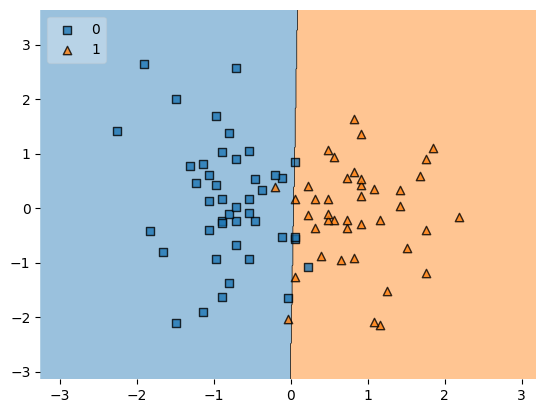

In [33]:


plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)
     


In [34]:
import pickle

In [35]:
pickle.dump(clf,open('model.pkl','wb'))